In [31]:
from PipingSystem import PipingSystem
from Elements.Coil import Coil
from Elements.Singularities import SingularityLoss
from Elements.Tube import Tube
import CoolProp.CoolProp as cp
import numpy as np
from Pumps.Lauda import LaudaPumpFit
import matplotlib.pyplot as plt
from scipy.optimize import newton

Definimos serpentin

In [32]:
coil = Coil(d_in = 5.15e-3, d_out=6.35e-3, lenght=1, orientation=-90, material="copper", vueltas = 5, pitch=6.35e-3)

Definimos el sistema

In [33]:
fluxsys = PipingSystem()
fluxsys.add_tube(Tube(d_in = 9e-3, d_out = 11e-3, lenght=1.5, orientation=0, material="Plastic")) # Primera manguera del lauda
fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Primer cambio de diametro
fluxsys.add_coil(coil) # Serpentin
fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Segundo cambio de diamtro
fluxsys.add_tube(Tube(d_in = 9e-3, d_out = 11e-3, lenght=1.5, orientation=0, material="Plastic")) # Segunda manguera del lauda
fluxsys.conect() # Conectar

Definimos el Fluido

In [34]:
tl = 273.15 + 1
pl = 101325        
mul = 0.002 # Pa*s
rhol = 987.14 # kg/m3
cpl = 4267 # J /(kg K)
kl = 0.4984 # W/(m K)
prl = mul*cpl/kl
print(prl, kl)

17.12279293739968 0.4984


Buscamos donde cruza la curva del sistema con la curva de la bomba

In [35]:
fluxsys.cross_system_pump(rhol,mul, LaudaPumpFit.Pa4m3s, 3.25e-5,verbose=True);


═════════════════════════════════════════════
        UNTO DE OPERACIÓN DEL SISTEMA        
═════════════════════════════════════════════
 Caudal volumétrico :    1.979 L/min
 Caudal volumétrico      : 3.30e-05 m³/s
 Presión de cruce   :  17938.9 Pa
 Pérdida de altura  :    1.852 m.c.a.
═════════════════════════════════════════════



In [36]:
m_dot = 3.23e-5*rhol

def calcular_salida_serpentin(twater, tin, twall_init=283.15, tout_init=280.15):
    # Parámetros de convergencia y control (Diagrama image_fdb19a.png)
    tol = 0.01
    relax = 0.01
    max_iter = 100
    
    tout = tout_init
    twall = twall_init
    
    # BUCLE EXTERNO: Para encontrar la temperatura de salida (Tout)
    for i in range(max_iter):
        
        # BUCLE INTERNO: Para encontrar la temperatura de pared (Twall)
        # Basado en el bloque "Compute" 1 de image_fd399a.png
        for j in range(max_iter):
            # 1) Tfi (Temperatura de película interna)
            tfi = (twall + (tin + tout) / 2) / 2
            
            # 3) Reynolds interno
            Re = (4 * m_dot) / (np.pi * coil.d_in * mul)
            
            # 4) Nusselt interno (Rogers and Mayhew)
            Nu = 0.021 * (Re**0.85) * (prl**0.4) * (coil.d_in / coil.curvature_d)**0.1
            
            # 5) hi (Coeficiente de transferencia interno)
            hi = Nu * kl / coil.d_in
            
            # 6) q (Transferencia de calor)
            q = m_dot * cpl * (tin - tout)
            
            # 7) Tw* calculada internamente
            twall_star_int = -q / (hi * coil.area_in) + (tin + tout) / 2
            
            # Verificación de convergencia de Twall (Is Tw* = Tw +- 0.01?)
            if abs(twall_star_int - twall) < tol:
                twall = twall_star_int
                break
            twall = twall_star_int

        # BLOQUE DE CÓMPUTO 2: Lado del baño (Convección natural)
        # 1) dTw (Caída de temperatura en la pared del tubo por conducción)
        # Nota: Usamos kw (conductividad del metal)
        dtwall = q * np.log(coil.d_out / coil.d_in) / (2 * np.pi * coil.conductivity * coil.lenght)
        
        # 2) Tfo (Temperatura de película externa)
        tfo = (twater + (twall + dtwall)) / 2
        
        # Propiedades del baño evaluadas en Tfo
        beta = cp.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', tfo, 'P', 101325, "water")
        prandtl = cp.PropsSI('Prandtl', 'T', tfo, 'P', 101325, "water")
        mu_o = cp.PropsSI('V', 'T', tfo, 'P', 101325, "water")
        rho_o = cp.PropsSI('D', 'T', tfo, 'P', 101325, "water")
        k_bath = cp.PropsSI('L', 'T', tfo, 'P', 101325, "water")
        nu_o = mu_o / rho_o
        
        # 3) Rayleigh (Usando altura del serpentín según image_fc4239.png)
        gr = (9.81 * beta * abs((twall + dtwall) - twater) * (coil.altura**3)) / (nu_o**2)
        Ra = gr * prandtl
        
        # 4) Nusselt externo (Tu correlación experimental)
        Nuo = 0.0749 * (Ra**0.3421) 
        
        # 5) ho
        ho = Nuo * k_bath / coil.altura
        
        # 6) Tw* calculada externamente (Balance de energía exterior)
        twall_star_ext = twater + q / (ho * coil.area_out) - dtwall
        
        # Verificación de convergencia externa (Is Tw* = Tw +- 0.01?)
        if abs(twall_star_ext - twall) < tol:
            print("encontrado")
            break
        
        # Ajuste de Tout mediante el factor de relajación (Paso final de image_fdb19a.png)
        tout = tout + (twall_star_ext - twall) * relax
        
    return tout, twall

In [37]:
calcular_salida_serpentin(20+273, 0+273)

encontrado


(np.float64(273.6263754431269), np.float64(274.2530944187393))

Iniciando simulación de 20 minutos...
Simulación finalizada.


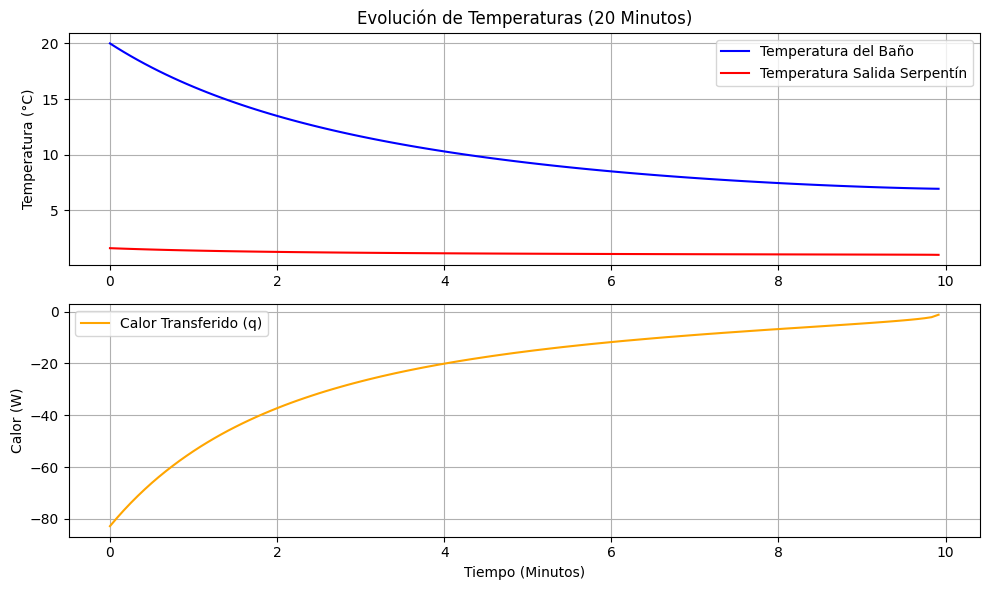

In [38]:
import numpy as np
import CoolProp.CoolProp as cp
import matplotlib.pyplot as plt

# --- NOTA: Asegúrate de tener definidos tus parámetros previos aquí ---
m_dot = 3.23e-5*rhol
# coil = TuClaseSerpentin(...)
# cpl, kl, mul, prl, rhol = ... (Propiedades del fluido interno)

def calcular_salida_serpentin(twater, tin, twall_init=283.15, tout_init=280.15):
    """
    Calcula la temperatura de salida del serpentín, la temperatura de pared
    y el calor transferido en un instante dado.
    """
    tol = 0.1
    relax = 0.001
    max_iter = 1000
    
    tout = tout_init
    twall = twall_init
    q = 0 # Inicializar q por si el bucle falla
    
    # BUCLE EXTERNO: Para encontrar la temperatura de salida (Tout)
    for i in range(max_iter):
        
        # BUCLE INTERNO: Para encontrar la temperatura de pared (Twall)
        for j in range(max_iter):
            # 1) Tfi (Temperatura de película interna)
            tfi = (twall + (tin + tout) / 2) / 2
            
            # 3) Reynolds interno
            Re = (4 * m_dot) / (np.pi * coil.d_in * mul)
            
            # 4) Nusselt interno (Rogers and Mayhew)
            Nu = 0.021 * (Re**0.85) * (prl**0.4) * (coil.d_in / coil.curvature_d)**0.1
            
            # 5) hi (Coeficiente de transferencia interno)
            hi = Nu * kl / coil.d_in
            
            # 6) q (Transferencia de calor)
            q = m_dot * cpl * (tin - tout)
            
            # 7) Tw* calculada internamente
            twall_star_int = -q / (hi * coil.area_in) + (tin + tout) / 2
            
            # Verificación de convergencia de Twall
            if abs(twall_star_int - twall) < tol:
                twall = twall_star_int
                break
            twall = twall_star_int

        # BLOQUE DE CÓMPUTO 2: Lado del baño (Convección natural)
        dtwall = q * np.log(coil.d_out / coil.d_in) / (2 * np.pi * coil.conductivity * coil.lenght)
        
        # 2) Tfo (Temperatura de película externa)
        tfo = (twater + (twall + dtwall)) / 2
        
        # --- 1er FILTRO: Atrapar el NaN correctamente ---
        if np.isnan(tfo):
            # Si el cálculo explota, lo reseteamos a un valor seguro
            tfo = 273.20
            twall = 273.20
            
        # --- 2do FILTRO: Límite de congelación ---
        if tfo < 273.16:
            tfo = 273.20 # Forzar un valor justo por encima de la congelación

        # Propiedades del baño evaluadas en Tfo
        beta = cp.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', tfo, 'P', 101325, "water")
        prandtl = cp.PropsSI('Prandtl', 'T', tfo, 'P', 101325, "water")
        mu_o = cp.PropsSI('V', 'T', tfo, 'P', 101325, "water")
        rho_o = cp.PropsSI('D', 'T', tfo, 'P', 101325, "water")
        k_bath = cp.PropsSI('L', 'T', tfo, 'P', 101325, "water")
        nu_o = mu_o / rho_o
        
        # --- 3er FILTRO: Prevenir división por cero ---
        delta_T = abs((twall + dtwall) - twater)
        if delta_T < 0.01:
            delta_T = 0.01 # Evita que la diferencia de temperatura sea cero puro
            
        # 3) Rayleigh
        gr = (9.81 * beta * delta_T * (coil.altura**3)) / (nu_o**2)
        Ra = gr * prandtl
        
        # 4) Nusselt externo
        Nuo = 0.0749 * (Ra**0.3421) 
        
        # 5) ho
        ho = Nuo * k_bath / coil.altura
        
        # Guardarraíl para ho: Nunca debe ser menor a un mínimo físico razonable en agua (~10 W/m2K)
        if ho < 10.0:
            ho = 10.0
        
        # 6) Tw* calculada externamente
        twall_star_ext = twater + q / (ho * coil.area_out) - dtwall
        
        # Verificación de convergencia externa
        if abs(twall_star_ext - twall) < tol:
            break
        
        # Ajuste de Tout mediante el factor de relajación
        # Limitamos el salto por iteración a +/- 5 grados máximo para mayor estabilidad
        paso_relax = (twall_star_ext - twall) * relax
        paso_relax = np.clip(paso_relax, -5.0, 5.0) 
        tout = tout + paso_relax
        
    # RETORNO CORREGIDO: Ahora incluye 'q'
    return tout, twall, q


# --- SIMULACIÓN TRANSITORIA (20 MINUTOS) ---

M_tanque = 0.25 # Masa de agua en el baño (kg)
Cp_tanque = 4180  # J/kgC (Calor específico del agua)
dt = 5          # Paso de tiempo en segundos
tiempo_total = 10*60 # 20 minutos en segundos

# Condiciones iniciales de la simulación
t_bath_actual = 293.15 # Temperatura inicial del baño (Ej: 20°C en Kelvin)
tin = 273.15+1           # Temperatura de entrada al serpentín (Ej: 80°C en Kelvin)

# Listas para guardar el historial y graficar después
historial_tiempo = []
historial_t_bath = []
historial_tout = []
historial_q = []

print("Iniciando simulación de 20 minutos...")

for t in np.arange(0, tiempo_total, dt):
    # 1. Obtener temperaturas y calor instantáneo (Pasamos t_bath_actual y tin)
    # Se usan los valores de la iteración anterior como "guess" inicial (opcional pero hace el código más rápido)
    if t == 0:
        tout, twall, q = calcular_salida_serpentin(t_bath_actual, tin)
    else:
        # Reutilizamos el último tout y twall calculados para acelerar la convergencia
        tout, twall, q = calcular_salida_serpentin(t_bath_actual, tin, twall_init=twall, tout_init=tout)
    
    # 2. Guardar datos actuales en el historial
    historial_tiempo.append(t / 60.0) # Guardar en minutos
    historial_t_bath.append(t_bath_actual - 273.15) # Guardar en Celsius para fácil lectura
    historial_tout.append(tout - 273.15)
    historial_q.append(q)
    
    # 3. Calcular el cambio de temperatura del baño
    dT_bath = (q * dt) / (M_tanque * cp.PropsSI('C', 'T', t_bath_actual, 'P', 101325, "water"))
    
    # 4. Actualizar temperatura para el siguiente segundo
    t_bath_actual += dT_bath

print("Simulación finalizada.")

# --- VISUALIZACIÓN DE RESULTADOS ---

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(historial_tiempo, historial_t_bath, label="Temperatura del Baño", color='blue')
plt.plot(historial_tiempo, historial_tout, label="Temperatura Salida Serpentín", color='red')
plt.title("Evolución de Temperaturas (20 Minutos)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(historial_tiempo, historial_q, label="Calor Transferido (q)", color='orange')
plt.xlabel("Tiempo (Minutos)")
plt.ylabel("Calor (W)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()